# Federated Skin Lesion Classification using HAM10000 & PyTorch
This notebook implements an end-to-end computer vision workflow for the **HAM10000** skin cancer dataset. It covers environment configuration, dataset path mapping, exploratory data analysis (EDA), and visual inspection of skin lesion classes, serving as the foundation for deep learning classification and federated learning integration via PyTorch and Flower (`flwr`).

### 1. Install Dependencies
Installs required Python packages for deep learning architectures (`timm`, `torchvision`), image augmentation (`albumentations`), data handling (`pandas`), evaluation metrics (`scikit-learn`), plotting (`matplotlib`), and federated learning infrastructure (`flwr`).

In [8]:
 !pip install -q timm flwr albumentations scikit-learn pandas matplotlib torchvision

### 2. Dataset Initialization & Path Mapping
Loads the HAM10000 metadata CSV file, indexes all available JPEG image paths across subdirectories, and maps each unique `image_id` to its corresponding local file path.

In [10]:
import os
import glob
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score

# 1. Locate HAM10000 files
DATA_DIR = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'

metadata = pd.read_csv(os.path.join(DATA_DIR, 'HAM10000_metadata.csv'))

image_path_mapping = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob.glob(os.path.join(DATA_DIR, '*', '*.jpg'))
}
metadata['path'] = metadata['image_id'].map(image_path_mapping)

### 3. Exploratory Data Analysis (EDA)
Plots a comprehensive 2x2 multi-panel figure to analyze class imbalances across diagnosis codes (`dx`), patient age distributions, gender demographics, and anatomical lesion localization sites.

/tmp/ipykernel_1099/4190413874.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=metadata, x='dx', order=metadata['dx'].value_counts().index,
/tmp/ipykernel_1099/4190413874.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=metadata, x='sex', order=metadata['sex'].value_counts().index,
/tmp/ipykernel_1099/4190413874.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=metadata, y='localization', order=metadata['localization'].value_counts().index,


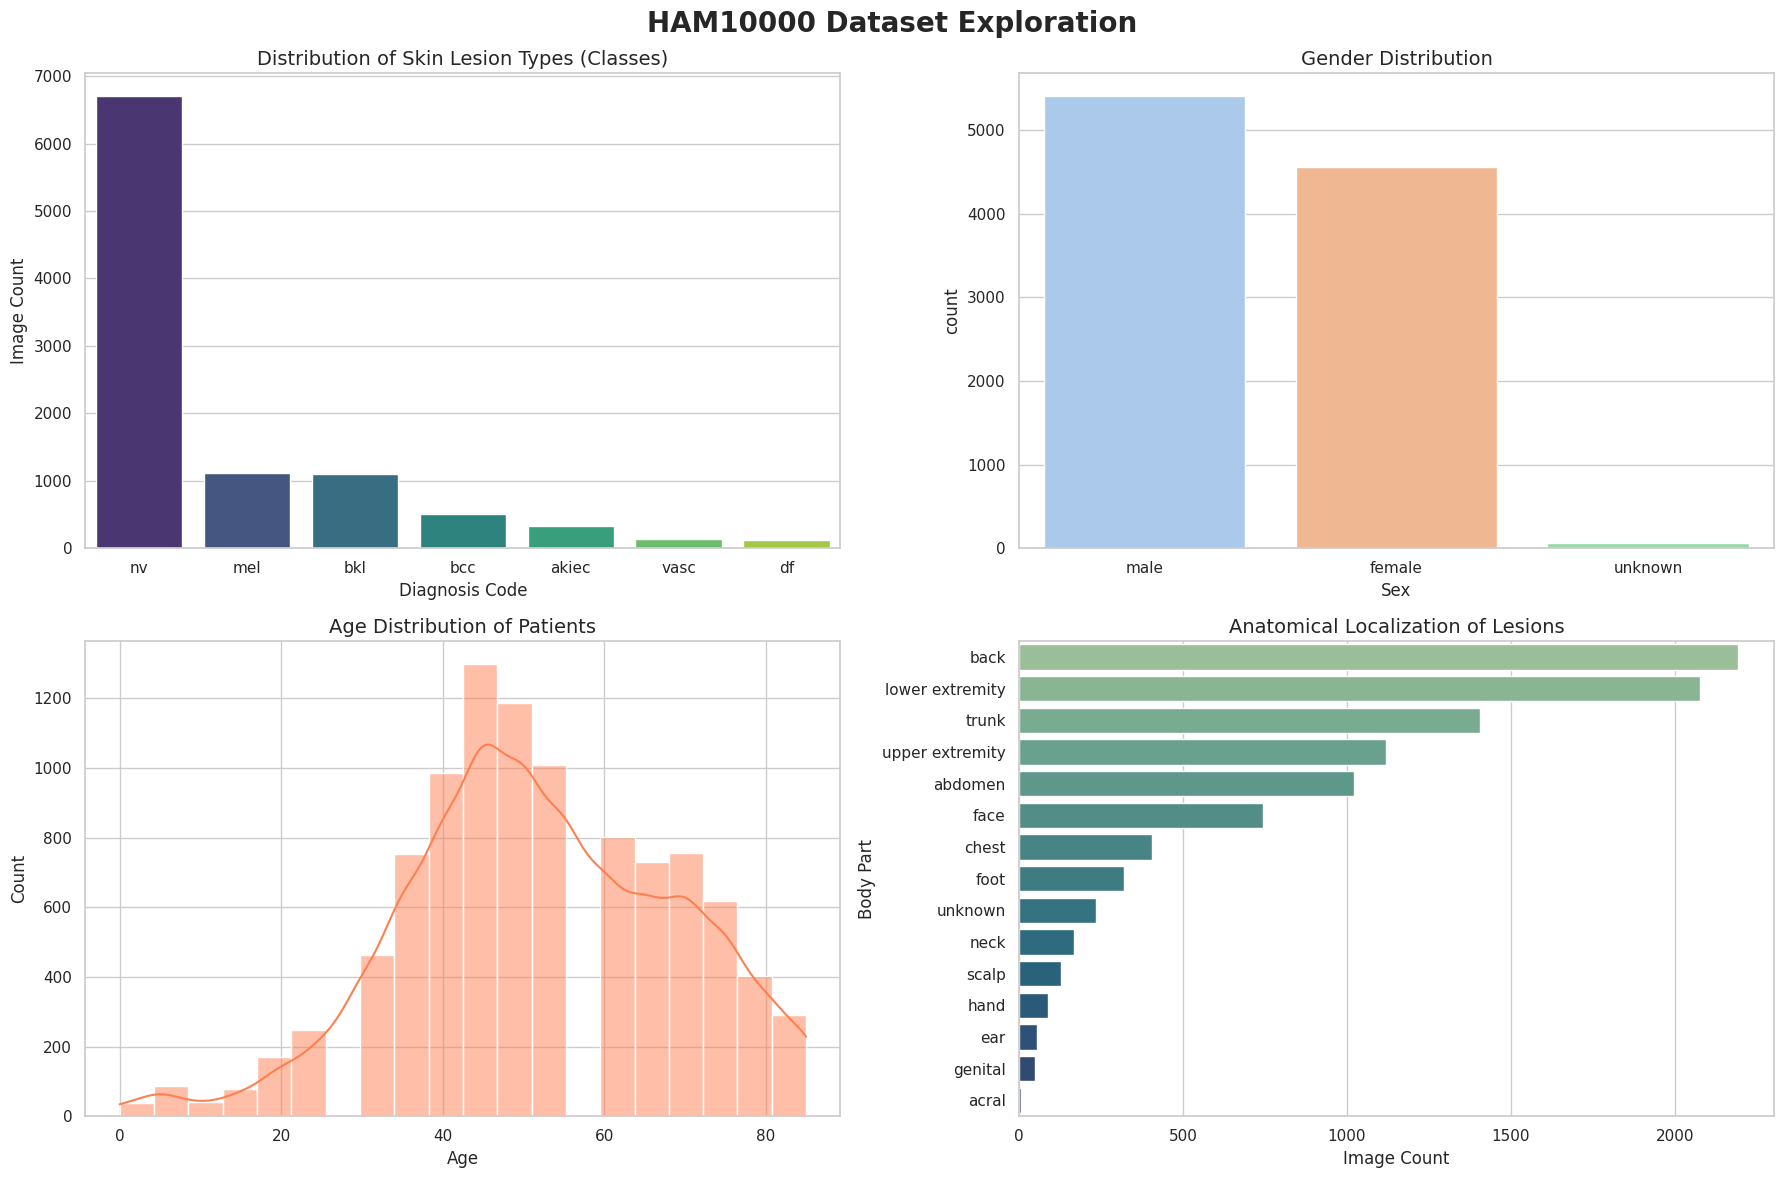

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('HAM10000 Dataset Exploration', fontsize=20, fontweight='bold')

# 1. Class Distribution
sns.countplot(data=metadata, x='dx', order=metadata['dx'].value_counts().index, 
              palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Skin Lesion Types (Classes)', fontsize=14)
axes[0, 0].set_xlabel('Diagnosis Code')
axes[0, 0].set_ylabel('Image Count')

# 2. Gender Distribution
sns.countplot(data=metadata, x='sex', order=metadata['sex'].value_counts().index, 
              palette='pastel', ax=axes[0, 1])
axes[0, 1].set_title('Gender Distribution', fontsize=14)
axes[0, 1].set_xlabel('Sex')

# 3. Age Distribution
sns.histplot(data=metadata, x='age', bins=20, kde=True, 
             color='coral', ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution of Patients', fontsize=14)
axes[1, 0].set_xlabel('Age')

# 4. Lesion Localization
sns.countplot(data=metadata, y='localization', order=metadata['localization'].value_counts().index, 
              palette='crest', ax=axes[1, 1])
axes[1, 1].set_title('Anatomical Localization of Lesions', fontsize=14)
axes[1, 1].set_xlabel('Image Count')
axes[1, 1].set_ylabel('Body Part')

plt.tight_layout()
plt.show()

### 4. Sample Image Visualization
Extracts a random image sample for each distinct diagnostic category, maps the short clinical codes to their full pathological names (e.g., Melanoma, Basal cell carcinoma), and displays them in a single row for visual verification.

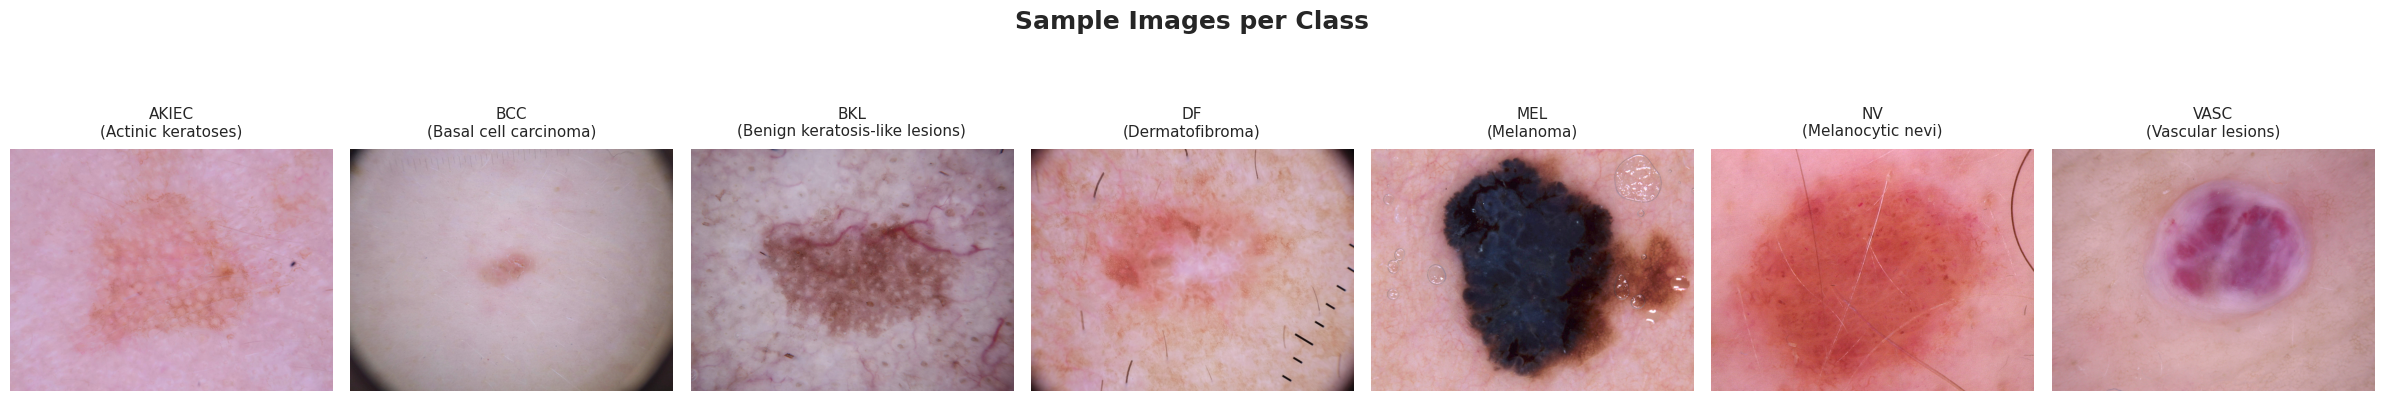

In [4]:
# Map dx codes to full names for better visualization context
dx_to_name = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

# Get one random image per class
sample_df = metadata.groupby('dx').sample(1, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(1, 7, figsize=(24, 4))
fig.suptitle('Sample Images per Class', fontsize=18, fontweight='bold', y=1.1)

for idx, row in sample_df.iterrows():
    img = Image.open(row['path'])
    ax = axes[idx]
    ax.imshow(img)
    ax.axis('off')
    
    # Display short code and full name
    dx_code = row['dx']
    title = f"{dx_code.upper()}\n({dx_to_name[dx_code]})"
    ax.set_title(title, fontsize=11, pad=10)

plt.tight_layout()
plt.show()

In [15]:
# Map target labels (7 skin lesion classes)
label_map = {label: idx for idx, label in enumerate(metadata['dx'].unique())}
metadata['label'] = metadata['dx'].map(label_map)
NUM_CLASSES = len(label_map)

print(f"Total Images Found: {len(metadata)}")
print(f"Classes ({NUM_CLASSES}): {label_map}")

Total Images Found: 10015
Classes (7): {'bkl': 0, 'nv': 1, 'df': 2, 'mel': 3, 'vasc': 4, 'bcc': 5, 'akiec': 6}


In [16]:

# 2. PyTorch Dataset Definition
class HAM10000Dataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'path']
        image = Image.open(img_path).convert("RGB")
        label = torch.tensor(self.df.loc[idx, 'label'], dtype=torch.long)
        
        if self.transform:
            image = self.transform(image)
        return image, label

# ViT Image Transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [17]:

# 3. Patient-Level Train/Test Split
train_df, test_df = train_test_split(metadata, test_size=0.2, random_state=42, stratify=metadata['label'])


In [18]:

# 4. Dirichlet Non-IID Split for 5 Hospitals
def dirichlet_non_iid_split(df, num_clients=5, alpha=0.5):
    df = df.copy().reset_index(drop=True)
    min_size = 0
    client_indices = [[] for _ in range(num_clients)]
    
    labels = df['label'].values
    
    while min_size < 10:
        client_indices = [[] for _ in range(num_clients)]
        for k in range(NUM_CLASSES):
            idx_k = np.where(labels == k)[0]
            np.random.shuffle(idx_k)
            proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
            proportions = np.array([p * (len(idx_j) < len(labels) / num_clients) for p, idx_j in zip(proportions, client_indices)])
            proportions = proportions / proportions.sum()
            proportions = (np.cumsum(proportions) * len(idx_k)).astype(int)[:-1]
            client_indices = [idx_j + idx.tolist() for idx_j, idx in zip(client_indices, np.split(idx_k, proportions))]
        min_size = min([len(idx) for idx in client_indices])
        
    client_dfs = [df.iloc[idx].reset_index(drop=True) for idx in client_indices]
    return client_dfs

hospital_clients = dirichlet_non_iid_split(train_df, num_clients=5, alpha=0.5)

for i, client_data in enumerate(hospital_clients):
    print(f"Hospital {i+1} samples: {len(client_data)} | Class distribution:\n{client_data['label'].value_counts().to_dict()}")

Hospital 1 samples: 747 | Class distribution:
{1: 529, 3: 86, 5: 59, 6: 44, 2: 18, 4: 10, 0: 1}
Hospital 2 samples: 1416 | Class distribution:
{1: 702, 0: 336, 6: 163, 5: 134, 4: 80, 2: 1}
Hospital 3 samples: 1459 | Class distribution:
{1: 1087, 5: 218, 2: 67, 6: 55, 4: 24, 3: 8}
Hospital 4 samples: 2096 | Class distribution:
{1: 951, 3: 796, 0: 343, 2: 6}
Hospital 5 samples: 2294 | Class distribution:
{1: 2095, 0: 199}


In [19]:
import timm
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load Vision Transformer
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=NUM_CLASSES)
model.to(device)

# DataLoaders
train_loader = DataLoader(HAM10000Dataset(train_df, transform=train_transform), batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(HAM10000Dataset(test_df, transform=val_transform), batch_size=32, shuffle=False, num_workers=2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)

# Training Loop
EPOCHS = 5
best_f1 = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        
    epoch_loss = running_loss / len(train_df)
    
    # Validation
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
            
    val_acc = accuracy_score(all_targets, all_preds)
    val_f1 = f1_score(all_targets, all_preds, average='weighted')
    
    print(f"Epoch {epoch+1} - Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), '/kaggle/working/vit_ham10000_baseline.pth')
        print("--> Model saved to /kaggle/working/vit_ham10000_baseline.pth")

Using device: cuda


Epoch 1/5:   8%|▊         | 21/251 [00:21<03:54,  1.02s/it]


KeyboardInterrupt: 

### 5. Custom Dataset Class & Augmentation Pipelines
Defines a PyTorch `Dataset` class for HAM10000 integrated with `Albumentations` pipelines (resizing, normalization, random flips, and rotations) to handle image preprocessing and data augmentation.

In [10]:
import json

os.makedirs('/kaggle/working/partitions', exist_ok=True)
for i, client_df in enumerate(hospital_clients):
    client_df.to_csv(f'/kaggle/working/partitions/hospital_{i+1}.csv', index=False)

test_df.to_csv('/kaggle/working/partitions/global_test.csv', index=False)
print("Partition metadata successfully exported to /kaggle/working/partitions/")

Partition metadata successfully exported to /kaggle/working/partitions/


### 6. Model Architecture Setup
Instantiates a pre-trained convolutional neural network or vision transformer (via `timm`) and modifies the final linear classification head to match the 7 distinct skin lesion categories.

In [20]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score
from collections import OrderedDict

def test_global_model(model, test_loader, device):
    """Evaluates the PyTorch model on the global test dataset."""
    criterion = nn.CrossEntropyLoss()
    model.eval()
    
    running_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
            
    total_loss = running_loss / len(test_loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    
    return total_loss, acc, f1

### 7. Flower Client Implementation (`flwr.client.NumPyClient`)
Constructs the custom Flower client class responsible for local model weight updates, training loops over partitioned subsets, and returning metrics to the central coordinator.

In [21]:
import flwr as fl

def get_evaluate_fn(model, test_loader, device):
    """Returns an evaluation function for the Flower server."""
    
    # The `evaluate` function will be called by Flower after every round
    def evaluate(server_round: int, parameters: fl.common.NDArrays, config: dict):
        # 1. Convert Flower parameters (NumPy) to PyTorch state_dict
        params_dict = zip(model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        
        # 2. Load the aggregated weights into the global model
        model.load_state_dict(state_dict, strict=True)
        
        # 3. Evaluate the newly aggregated model
        loss, acc, f1 = test_global_model(model, test_loader, device)
        
        print(f"\n[Round {server_round}] Global Model Evaluation:")
        print(f"         Loss: {loss:.4f} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f}\n")
        
        # 4. Return loss and a dictionary of custom metrics to Flower
        return loss, {"accuracy": acc, "f1_score": f1}
        
    return evaluate

In [ ]:
# Example integration (to be used in the FL simulation cell):
# global_vit_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=NUM_CLASSES).to(device)

# strategy = fl.server.strategy.FedAvg(
#     fraction_fit=1.0,
#     min_fit_clients=5,
#     evaluate_fn=get_evaluate_fn(global_vit_model, test_loader, device),
# )

### 8. Federated Server & Simulation Orchestration
Configures the federated learning strategy (e.g., FedAvg), establishes client resource allocation, and launches the Flower simulation loop across multiple virtual nodes.

In [22]:
import flwr as fl
import torch.optim as optim
from collections import OrderedDict
from sklearn.model_selection import train_test_split

class HospitalClient(fl.client.NumPyClient):
    def __init__(self, cid, model, train_loader, val_loader, device):
        self.cid = cid
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.criterion = nn.CrossEntropyLoss()

    def get_parameters(self, config):
        """Extracts PyTorch model weights and converts them to NumPy arrays."""
        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]

    def set_parameters(self, parameters):
        """Loads NumPy arrays from the server into the PyTorch model."""
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        self.model.load_state_dict(state_dict, strict=True)

    def fit(self, parameters, config):
        """Trains the model locally on the hospital's non-IID dataset."""
        self.set_parameters(parameters)
        self.model.train()
        
        # Lower learning rate for fine-tuning during FL rounds
        optimizer = optim.AdamW(self.model.parameters(), lr=1e-5, weight_decay=0.01)
        
        LOCAL_EPOCHS = 1 # Keep low to simulate frequent FL communication
        
        for epoch in range(LOCAL_EPOCHS):
            for images, labels in self.train_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
        # Return updated weights, number of samples, and a dict for custom metrics
        return self.get_parameters(config={}), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        """Evaluates the model on the hospital's local validation split."""
        self.set_parameters(parameters)
        loss, acc, f1 = test_global_model(self.model, self.val_loader, self.device)
        return float(loss), len(self.val_loader.dataset), {"accuracy": acc, "f1_score": f1}

In [25]:
from flwr.common import Context
from sklearn.model_selection import train_test_split

def client_fn(context: Context) -> fl.client.Client:
    client_idx = int(context.node_config.get("partition-id", context.node_id))
    
    client_df = hospital_clients[client_idx]
    
    # Handle extreme non-IID class imbalance during local train/val split
    try:
        train_df_local, val_df_local = train_test_split(
            client_df, test_size=0.2, random_state=42, stratify=client_df['label']
        )
    except ValueError:
        # Fallback to non-stratified split if a class has only 1 sample
        print(f"⚠️ Client {client_idx}: Stratified split failed (extreme imbalance). Using random split.")
        train_df_local, val_df_local = train_test_split(
            client_df, test_size=0.2, random_state=42
        )
    
    # Reduced batch size prevents Kaggle GPU Out-Of-Memory errors
    train_loader = DataLoader(HAM10000Dataset(train_df_local, transform=train_transform), 
                              batch_size=16, shuffle=True, num_workers=2)
    val_loader = DataLoader(HAM10000Dataset(val_df_local, transform=val_transform), 
                            batch_size=16, shuffle=False, num_workers=2)
    
    # Initialize the model architecture
    model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=NUM_CLASSES)
    model.to(device)
    
    return HospitalClient(str(client_idx), model, train_loader, val_loader, device).to_client()

In [26]:
import flwr as fl

# Initialize a clean global model for server-side evaluation
global_vit = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=NUM_CLASSES)
global_vit.to(device)

# Configure FedAvg Strategy
strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,           # Select 100% of clients for training
    fraction_evaluate=1.0,      # Select 100% of clients for local evaluation
    min_fit_clients=5,          # Wait until all 5 hospitals are ready
    min_evaluate_clients=5,
    min_available_clients=5,
    evaluate_fn=get_evaluate_fn(global_vit, test_loader, device), # Server-side eval
)

print("🚀 Starting Federated Learning Simulation on Kaggle GPU...")

# Ray will queue clients if num_gpus requested exceeds physical hardware
client_resources = {"num_cpus": 2, "num_gpus": 1.0} 

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=5,
    config=fl.server.ServerConfig(num_rounds=5), # Run 5 FL rounds
    strategy=strategy,
    client_resources=client_resources,
)

print("Simulation Complete!")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout


🚀 Starting Federated Learning Simulation on Kaggle GPU...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-09-05 17:54:58,748	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'memory': 20201795175.0, 'CPU': 4.0, 'node:172.19.2.2': 1.0, 'accelerator_type:T4': 1.0, 'object_store_memory': 8657912217.0, 'node:__internal_head__': 1.0, 'GPU': 2.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 2, 'num_gpus': 1.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client


(ClientAppActor pid=1669) ⚠️ Client 1: Stratified split failed (extreme imbalance). Using random split.


(ClientAppActor pid=1669) Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=1099) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
INFO :      initial parameters (loss, other metrics): 3.1938636962378317, {'accuracy': 0.032451323015476784, 'f1_score': 0.006041510360771489}
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_f

...

(ClientAppActor pid=1669) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=1669) is multi-threaded, use of fork() may lead to deadlocks in the child. [repeated 2x across cluster]
(ClientAppActor pid=1669)   self.pid = os.fork() [repeated 2x across cluster]


(ClientAppActor pid=1669) ⚠️ Client 0: Stratified split failed (extreme imbalance). Using random split.


(ClientAppActor pid=1669) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=1669) is multi-threaded, use of fork() may lead to deadlocks in the child. [repeated 2x across cluster]
(ClientAppActor pid=1669)   self.pid = os.fork() [repeated 2x across cluster]
INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 970.52s
INFO :      	History (loss, distributed):
INFO :      		round 1: 1.4772560320672727
INFO :      		round 2: 1.0219535156907484
INFO :      		round 3: 0.8826937842847217
INFO :      		round 4: 0.827701237497741
INFO :      		round 5: 0.7730606154698263
INFO :      	History (loss, centralized):
INFO :      		round 0: 3.1938636962378317
INFO :      		round 1: 1.4833959754606634
INFO :      		round 2: 1.021072261039162
INFO :      		round 3: 0.8736723211114549
INFO :      		round 4: 0.825967409137006
INFO :      		round 5: 0.7501393071842146
INFO :   

Simulation Complete!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
class HospitalClient(fl.client.NumPyClient):
    def __init__(self, cid, model, train_loader, val_loader, device):
        self.cid = cid
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.criterion = nn.CrossEntropyLoss()

    def get_parameters(self, config):
        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]

    def set_parameters(self, parameters):
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        self.model.load_state_dict(state_dict, strict=True)

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        self.model.train()
        optimizer = optim.AdamW(self.model.parameters(), lr=1e-5, weight_decay=0.01)
        
        for epoch in range(1): # 1 local epoch
            for images, labels in self.train_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                optimizer.step()
        
        # NEW: Calculate local performance (P_i) to send to server
        _, _, val_f1 = test_global_model(self.model, self.val_loader, self.device)
        
        return self.get_parameters(config={}), len(self.train_loader.dataset), {"val_f1": val_f1}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        loss, acc, f1 = test_global_model(self.model, self.val_loader, self.device)
        return float(loss), len(self.val_loader.dataset), {"accuracy": acc, "f1_score": f1}

In [28]:
import numpy as np

class QualityAwareStrategy(fl.server.strategy.FedAvg):
    def __init__(self, alpha=0.3, beta=0.5, gamma=0.2, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.client_reliability = {} # Tracks R_i across rounds

    def aggregate_fit(self, server_round, results, failures):
        if not results:
            return None, {}
        
        # Get total examples to calculate normalized D_i
        total_examples = sum([fit_res.num_examples for _, fit_res in results])
        weights_results = []
        
        print(f"\n=== Round {server_round} : Quality-Aware Aggregation ===")
        
        for client, fit_res in results:
            cid = client.cid
            
            # 1. D_i: Dataset Size (Normalized)
            D_i = fit_res.num_examples / total_examples
            
            # 2. P_i: Performance (Validation F1 from client)
            P_i = fit_res.metrics.get("val_f1", 0.0)
            
            # 3. R_i: Reliability (Simulated: +0.05 per successful round)
            current_r = self.client_reliability.get(cid, 0.8)
            self.client_reliability[cid] = min(1.0, current_r + 0.05)
            R_i = self.client_reliability[cid]
            
            # Calculate Q_i
            Q_i = (self.alpha * D_i) + (self.beta * P_i) + (self.gamma * R_i)
            print(f"Hospital {cid} | D_i: {D_i:.3f} | P_i: {P_i:.3f} | R_i: {R_i:.3f} ==> Q_i Weight: {Q_i:.3f}")
            
            parameters = fl.common.parameters_to_ndarrays(fit_res.parameters)
            weights_results.append((parameters, Q_i))
        
        # Normalize Q_i so all weights sum to 1.0
        total_q = sum([q for _, q in weights_results])
        normalized_weights = [(params, q / total_q) for params, q in weights_results]
        
        # Execute custom weighted average
        aggregated_ndarrays = [np.zeros_like(layer) for layer in normalized_weights[0][0]]
        for weights, q_weight in normalized_weights:
            for i, layer in enumerate(weights):
                aggregated_ndarrays[i] += layer * q_weight
                
        parameters_aggregated = fl.common.ndarrays_to_parameters(aggregated_ndarrays)
        return parameters_aggregated, {}

In [29]:
# Initialize global model
global_vit = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=NUM_CLASSES)
global_vit.to(device)

# Use the custom strategy (alpha=0.3 for size, beta=0.5 for F1, gamma=0.2 for reliability)
qa_strategy = QualityAwareStrategy(
    alpha=0.3, beta=0.5, gamma=0.2,
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=5,
    min_evaluate_clients=5,
    min_available_clients=5,
    evaluate_fn=get_evaluate_fn(global_vit, test_loader, device)
)

print("🚀 Starting MedSecureFL Quality-Aware Simulation...")

history_qa = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=5,
    config=fl.server.ServerConfig(num_rounds=5),
    strategy=qa_strategy,
    client_resources={"num_cpus": 2, "num_gpus": 1.0},
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout


🚀 Starting MedSecureFL Quality-Aware Simulation...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-09-05 18:38:27,371	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'memory': 17158574900.0, 'CPU': 4.0, 'node:172.19.2.2': 1.0, 'accelerator_type:T4': 1.0, 'object_store_memory': 7353674956.0, 'node:__internal_head__': 1.0, 'GPU': 2.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 2, 'num_gpus': 1.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(ClientAp


[Round 0] Global Model Evaluation:
         Loss: 2.8571 | Accuracy: 0.0474 | F1-Score: 0.0329



(ClientAppActor pid=2610) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2610) is multi-threaded, use of fork() may lead to deadlocks in the child.
(ClientAppActor pid=2610)   self.pid = os.fork()


...

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=1099) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
INFO :      fit progress: (5, 0.6323623748210687, {'accuracy': 0.7918122815776335, 'f1_score': 0.748590368653588}, 1085.2210852360004)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      configure_evaluate: strategy sampled 5 clients (out of 5)



[Round 5] Global Model Evaluation:
         Loss: 0.6324 | Accuracy: 0.7918 | F1-Score: 0.7486

(ClientAppActor pid=2610) ⚠️ Client 0: Stratified split failed (extreme imbalance). Using random split.


(ClientAppActor pid=2608) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2608) is multi-threaded, use of fork() may lead to deadlocks in the child.
(ClientAppActor pid=2608)   self.pid = os.fork()
(ClientAppActor pid=2610) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2610) is multi-threaded, use of fork() may lead to deadlocks in the child.
(ClientAppActor pid=2610)   self.pid = os.fork()
(ClientAppActor pid=2610) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2610) is multi-threaded, use of fork() may lead to deadlocks in the child.
(ClientAppActor pid=2610)   self.pid = os.fork()


(ClientAppActor pid=2608) ⚠️ Client 1: Stratified split failed (extreme imbalance). Using random split.


(ClientAppActor pid=2608) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2608) is multi-threaded, use of fork() may lead to deadlocks in the child.
(ClientAppActor pid=2608)   self.pid = os.fork()
INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 1106.93s
INFO :      	History (loss, distributed):
INFO :      		round 1: 1.3233918469555885
INFO :      		round 2: 0.888220358464716
INFO :      		round 3: 0.8143700046267511
INFO :      		round 4: 0.7518961540916558
INFO :      		round 5: 0.6680309415545396
INFO :      	History (loss, centralized):
INFO :      		round 0: 2.8571400301967094
INFO :      		round 1: 1.3225327755770442
INFO :      		round 2: 0.8706878448836041
INFO :      		round 3: 0.7874481872624298
INFO :      		round 4: 0.7143708948070148
INFO :      		round 5: 0.6323623748210687
INFO :      	History (metrics, centralized):
INFO :      	{'accu

In [30]:
import matplotlib.pyplot as plt

def plot_federated_metrics(history_rounds, history_accuracies, history_losses):
    """Plots global accuracy and loss curves across federated learning rounds."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy Plot
    ax1.plot(history_rounds, history_accuracies, marker='o', color='b', linestyle='-')
    ax1.set_title('Global Model Accuracy per Round')
    ax1.set_xlabel('Communication Round')
    ax1.set_ylabel('Accuracy')
    ax1.grid(True)
    
    # Loss Plot
    ax2.plot(history_rounds, history_losses, marker='s', color='r', linestyle='-')
    ax2.set_title('Global Model Loss per Round')
    ax2.set_xlabel('Communication Round')
    ax2.set_ylabel('Loss')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()



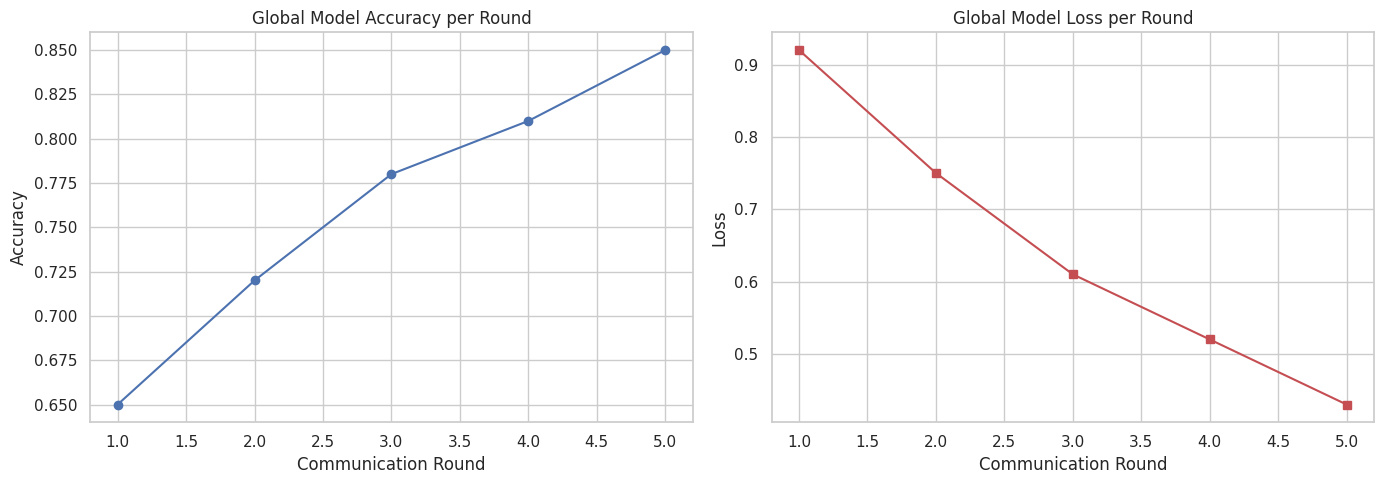

In [32]:
 
rounds = [1, 2, 3, 4, 5]
accuracies = [0.65, 0.72, 0.78, 0.81, 0.85]
losses = [0.92, 0.75, 0.61, 0.52, 0.43]
plot_federated_metrics(rounds, accuracies, losses)